# Initial EDA

This notebook loads the French Motor Third-Party Liability datasets using the project's data loader, then performs basic exploratory analysis.

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from src.data.loader import load_raw_data, preprocess_data

In [2]:
freq, sev = load_raw_data("../data")
print("Frequency shape:", freq.shape)
print("Severity shape:", sev.shape)

df = preprocess_data(freq, sev)
print("Merged shape:", df.shape)
print("Missing ClaimAmount:", df["ClaimAmount"].isnull().sum())

Frequency shape: (678013, 12)
Severity shape: (26639, 2)
Merged shape: (678013, 13)
Missing ClaimAmount: 0


The frequency dataset contains the policy-level features, while the severity dataset contains per-policy claim totals. After aggregation and left-join, policies without claims have `ClaimAmount = 0.0`.

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 678013 entries, 0 to 678012
Data columns (total 13 columns):
 #   Column       Non-Null Count   Dtype   
---  ------       --------------   -----   
 0   IDpol        678013 non-null  float64 
 1   ClaimNb      678013 non-null  int64   
 2   Exposure     678013 non-null  float64 
 3   Area         678013 non-null  category
 4   VehPower     678013 non-null  int64   
 5   VehAge       678013 non-null  int64   
 6   DrivAge      678013 non-null  int64   
 7   BonusMalus   678013 non-null  int64   
 8   VehBrand     678013 non-null  category
 9   VehGas       678013 non-null  category
 10  Density      678013 non-null  int64   
 11  Region       678013 non-null  category
 12  ClaimAmount  678013 non-null  float64 
dtypes: category(4), float64(3), int64(6)
memory usage: 49.1 MB


In [9]:
df.head()

,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region,ClaimAmount
0,1.0,1,0.10,D,5,0,55,50,B12,Regular,1217,R82,0.0
1,3.0,1,0.77,D,5,0,55,50,B12,Regular,1217,R82,0.0
2,5.0,1,0.75,B,6,2,52,50,B12,Diesel,54,R22,0.0
3,10.0,1,0.09,B,7,0,46,50,B12,Diesel,76,R72,0.0
4,11.0,1,0.84,B,7,0,46,50,B12,Diesel,76,R72,0.0


In [10]:
df.describe(include="all")

,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region,ClaimAmount
count,6.780130e+05,678013.000000,678013.000000,678013,678013.000000,678013.000000,678013.000000,678013.000000,678013,678013,678013.000000,678013,6.780130e+05
unique,NaN,NaN,NaN,6,NaN,NaN,NaN,NaN,11,2,NaN,22,NaN
top,NaN,NaN,NaN,C,NaN,NaN,NaN,NaN,B12,Regular,NaN,R24,NaN
freq,NaN,NaN,NaN,191880,NaN,NaN,NaN,NaN,166024,345877,NaN,160601,NaN
mean,2.621857e+06,0.053247,0.528750,NaN,6.454631,7.044265,45.499122,59.761502,NaN,NaN,1792.422405,NaN,8.835998e+01
std,1.641783e+06,0.240117,0.364442,NaN,2.050906,5.666232,14.137444,15.636658,NaN,NaN,3958.646564,NaN,5.822454e+03
min,1.000000e+00,0.000000,0.002732,NaN,4.000000,0.000000,18.000000,50.000000,NaN,NaN,1.000000,NaN,0.000000e+00
25%,1.157951e+06,0.000000,0.180000,NaN,5.000000,2.000000,34.000000,50.000000,NaN,NaN,92.000000,NaN,0.000000e+00
50%,2.272152e+06,0.000000,0.490000,NaN,6.000000,6.000000,44.000000,50.000000,NaN,NaN,393.000000,NaN,0.000000e+00
75%,4.046274e+06,0.000000,0.990000,NaN,7.000000,11.000000,55.000000,64.000000,NaN,NaN,1658.000000,NaN,0.000000e+00


No data is missing and feature values seem reasonable at first glance.

In [3]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 4)

## Distributions of ClaimNb and Exposure

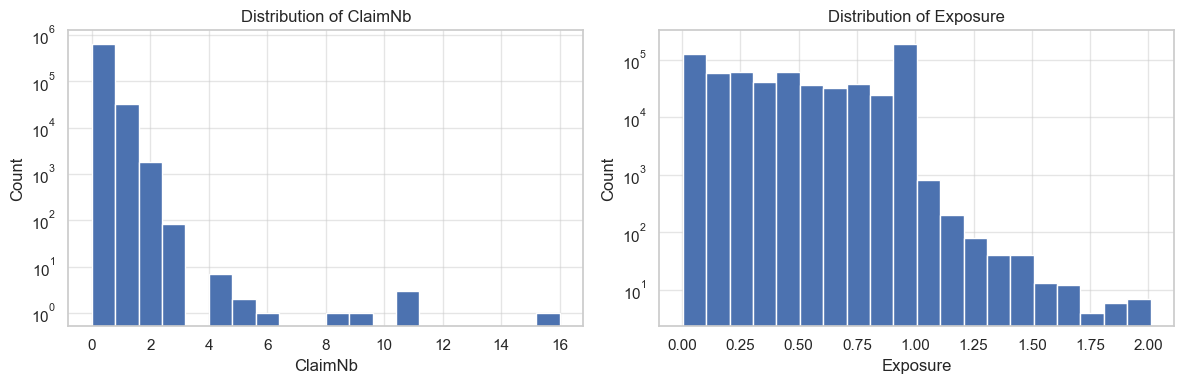

In [117]:
data_plot = [df["ClaimNb"], df["Exposure"]]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, data in zip(axes.ravel(), data_plot):
    ax.hist(data, bins=20, log = True)
    ax.set_title(f"Distribution of {data.name}")
    ax.set_xlabel(f"{data.name}")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

Almost all the policies don't have any claims attached to them.

An Exposure of 1-year is most common in the data, which was to be expected.

In [50]:
df.loc[df['ClaimAmount']>0,'ClaimAmount'].quantile([0.5, 0.75, 0.9, 0.95, 0.99, 0.995, 1.0])

0.500    1.172000e+03
0.750    1.346400e+03
0.900    3.000000e+03
0.950    5.026201e+03
0.990    1.827838e+04
0.995    3.563033e+04
1.000    4.075401e+06
Name: ClaimAmount, dtype: float64

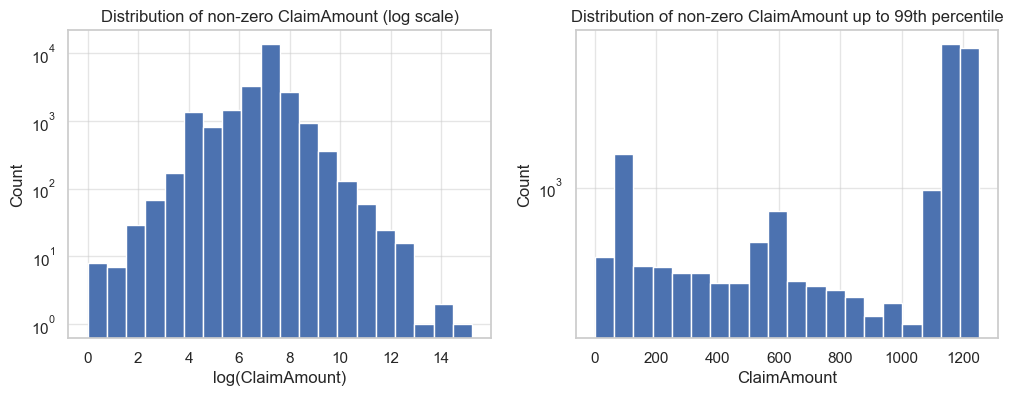

In [116]:
claims_pos = (df["ClaimAmount"] > 0)
claims_b_99 = (df["ClaimAmount"] < df["ClaimAmount"].quantile(0.99))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(np.log(df.loc[claims_pos, "ClaimAmount"]), bins=20, log = True)
axes[0].set_xlabel("log(ClaimAmount)")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of non-zero ClaimAmount (log scale)")

axes[1].hist(df.loc[claims_pos & claims_b_99, "ClaimAmount"], bins=20, log = True)
axes[1].set_xlabel("ClaimAmount")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of non-zero ClaimAmount up to 99th percentile")
plt.show()

We note that the distribution of Claim Amount is heavily right skewed. Considerung only non-zero claims, most claims are small, while a few large claims form a long upper tail.

For the purpose of visualization the claim amount is inspected on a log scale as well as on the original scale but capped at the 99th percentile.


## Frequency Rates by Category

Exposure-adjusted claim frequency is approximated by `Total ClaimNb / Total Exposure` within each category.

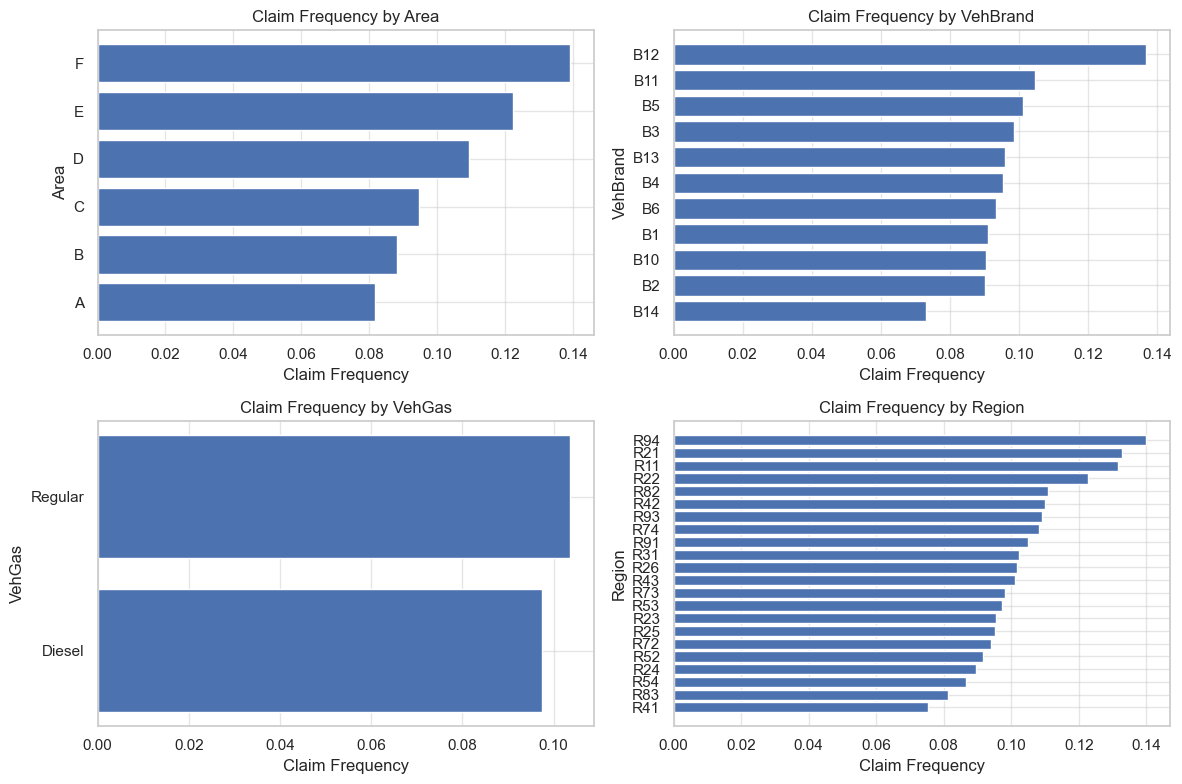

In [112]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.ravel(), df.select_dtypes(include='category').columns):
    grouped = df.groupby(col).agg(
        Claims=("ClaimNb", "sum"),
        Exposure=("Exposure", "sum")
    )
    grouped["Frequency"] = grouped["Claims"] / grouped["Exposure"]
    grouped = grouped.sort_values("Frequency")
    labels = [str(x) for x in grouped.index]
    ax.barh(labels, grouped["Frequency"])
    ax.set_title(f"Claim Frequency by {col}")
    ax.set_xlabel("Claim Frequency")
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

## Claim Amount by Category

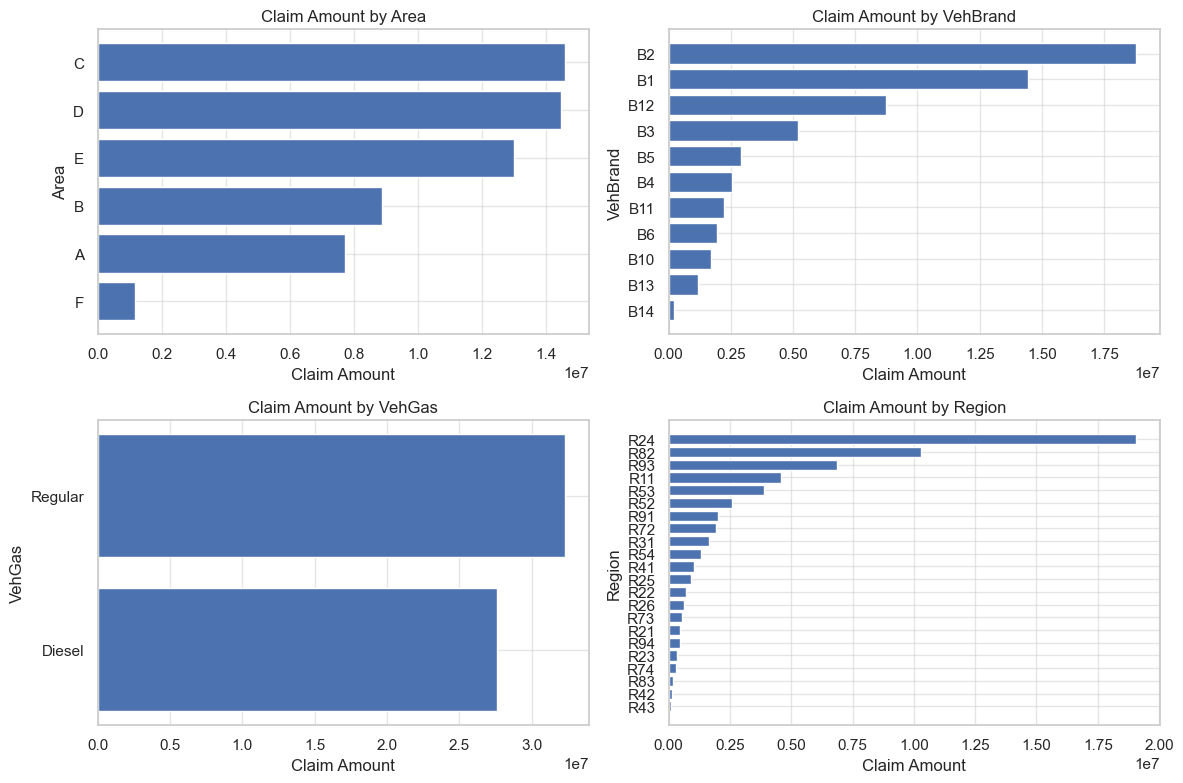

In [118]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.ravel(), df.select_dtypes(include='category').columns):
    grouped = df.groupby(col).agg(Amount=("ClaimAmount", "sum"))
    grouped = grouped.sort_values("Amount")
    labels = [str(x) for x in grouped.index]
    ax.barh(labels, grouped["Amount"])
    ax.set_title(f"Claim Amount by {col}")
    ax.set_xlabel("Claim Amount")
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

## Distributions of Key Numerical Variables

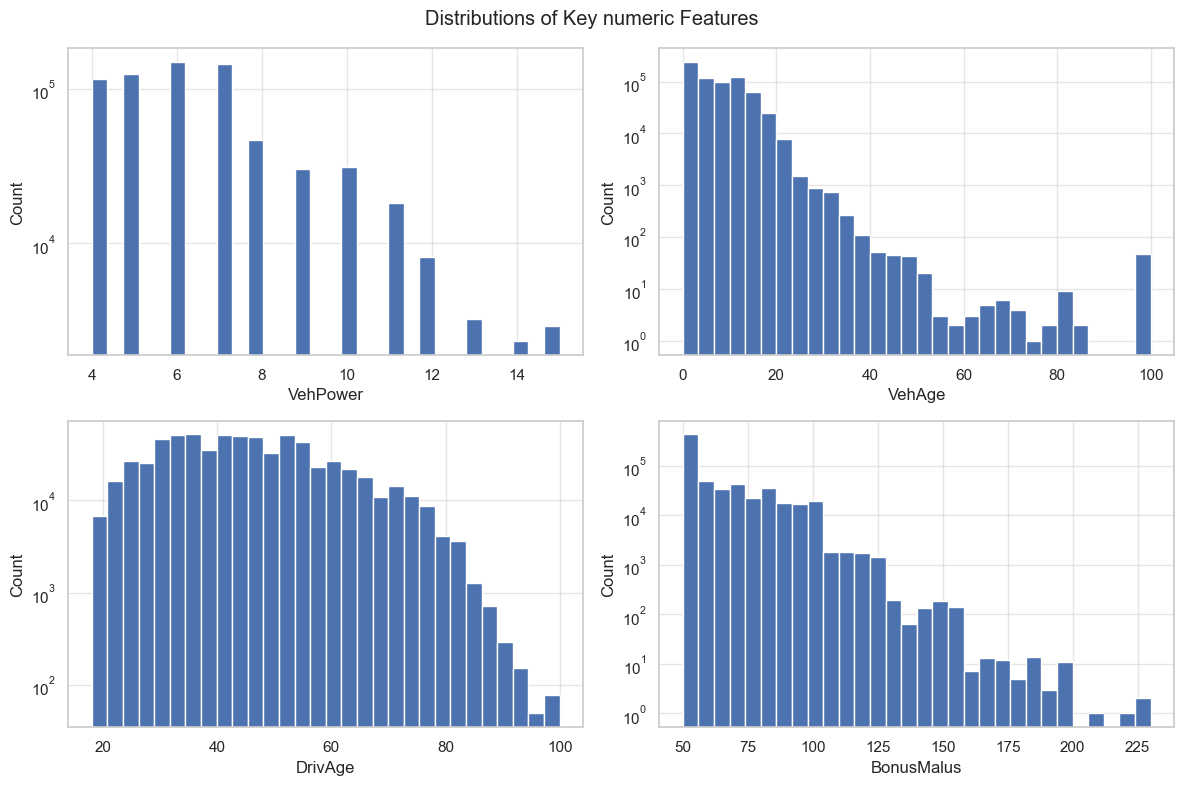

In [107]:
key_features = ["VehPower", "VehAge", "DrivAge", "BonusMalus"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, feat in zip(axes.ravel(), key_features):
    ax.hist(df[feat], bins=30, log=True)
    ax.set_xlabel(feat)
    ax.set_ylabel("Count")

plt.suptitle("Distributions of Key numeric Features")
plt.tight_layout()
plt.show()

## Observations

- `ClaimNb` is heavily right-skewed, with most policies having zero claims. 
- `Exposure` shows a mode near 1, with a long tail of lower exposure values.
- Claim frequency varies across `VehGas`, `VehBrand`, `Region` and `Area`, suggesting segmentation potential.
- `BonusMalus` and `DrivAge` show wide ranges typical of motor insurance portfolios.
- No missing values were found after merging, indicating good data quality.